In [23]:
import numpy as np
from OptimalBattery.util import build_combinations
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [18]:
n_tasks = 29
n_parcel = 32

In [19]:
VL_rand = Vs = np.random.normal(0, 1, (n_tasks, n_parcel))
GL_rand = VL_rand @ VL_rand.T

In [20]:
offsets = np.logspace(-10, 10, num=1000)

In [21]:
D = build_combinations(G_lib=GL_rand,strategy='random',n_iter=100,offs = offsets, n_tasks=6,seed=1)

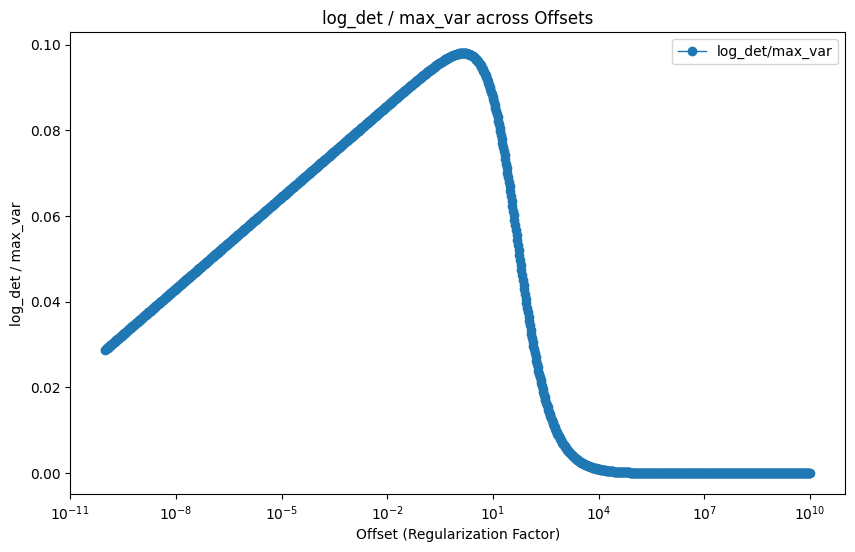

In [22]:
avg_metrics = D.groupby('offset')[['max_var', 'log_det']].mean()

avg_metrics['log_det_max_var_ratio'] = avg_metrics['log_det'] / avg_metrics['max_var']

plt.figure(figsize=(10, 6))
plt.plot(avg_metrics.index, avg_metrics['log_det_max_var_ratio'], label='log_det/max_var', marker='o', linewidth=1)

plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('log_det / max_var')
plt.title('log_det / max_var across Offsets')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Correlation between log_det and max_var across Offsets')

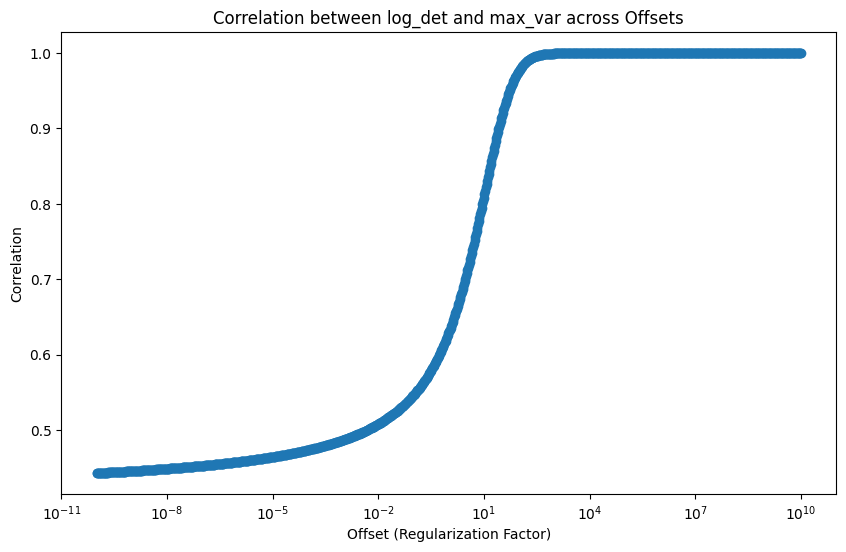

In [24]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D[D['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between log_det and max_var across Offsets')



Text(0.5, 1.0, 'Correlation between min_est and max_var across Offsets')

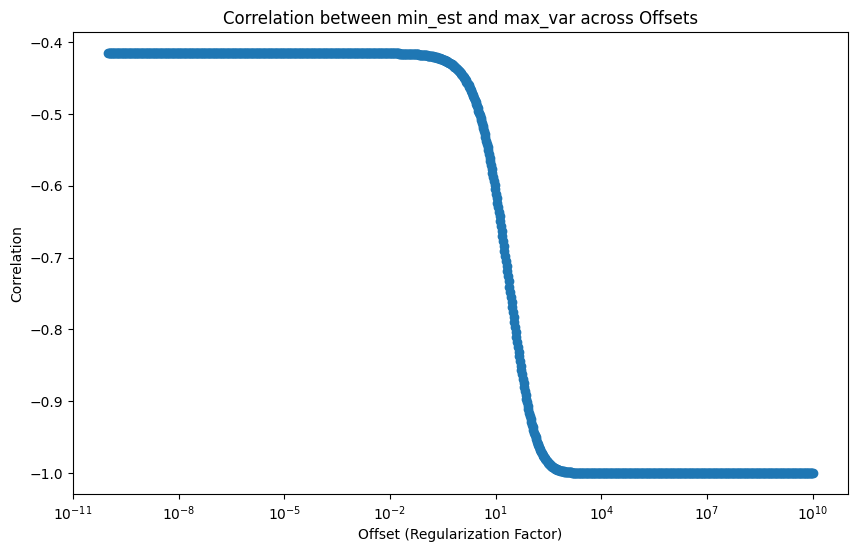

In [25]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D[D['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['min_est'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and max_var across Offsets')

Text(0.5, 1.0, 'Correlation between min_est and log_det across Offsets')

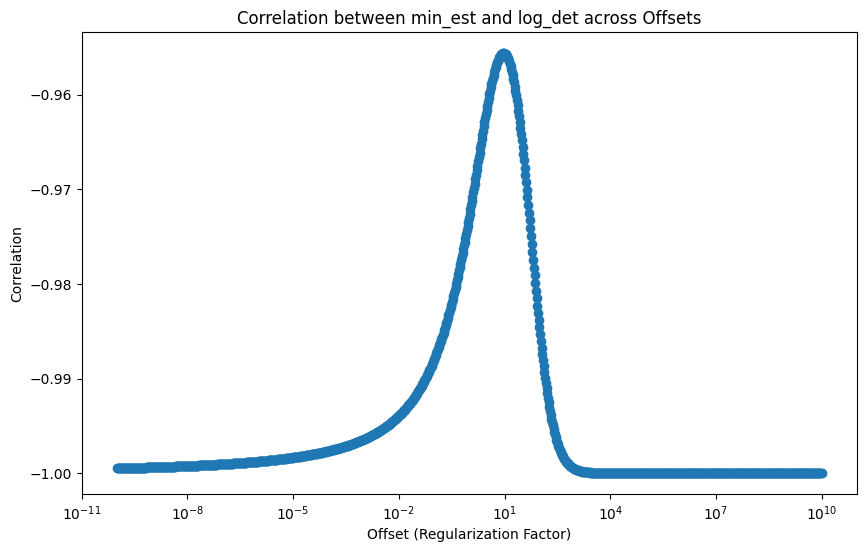

In [26]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D[D['offset'] == offset]
    corr, _ = pearsonr(data['min_est'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and log_det across Offsets')

# mdtb covariance

<Axes: >

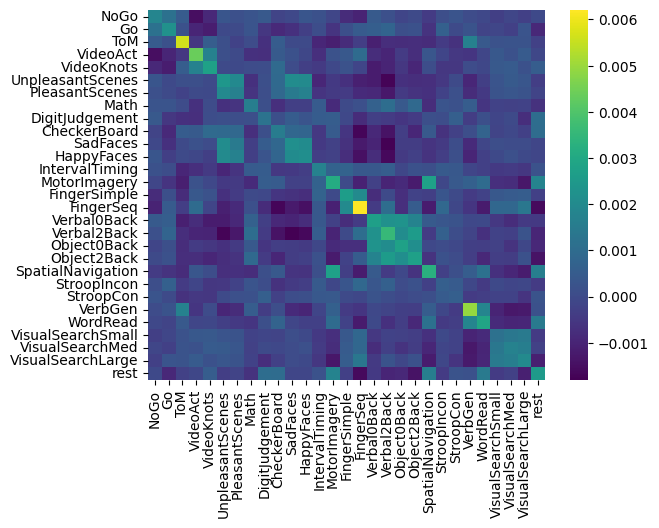

In [16]:
from IndividualParcellation.global_config import *
import numpy as np
import seaborn as sns
from Functional_Fusion.dataset import DataSetMDTB
import Functional_Fusion.atlas_map as am
import PcmPy as pcm
import os

base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'
space = 'SUIT3'
atlas, _ = am.get_atlas(space)


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
task_names = info_mdtb_1.cond_name.values


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

task_matrix = data_mdtb_s1 
task_matrix[np.isnan(task_matrix)] = 0

cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(task_matrix.shape[0]):
    Gs,E = pcm.util.est_G_crossval(task_matrix[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

In [29]:
D_mdtv = build_combinations(G_lib=G_individuals_averaged,strategy='random',n_iter=100,offs = offsets, n_tasks=8,seed=1)

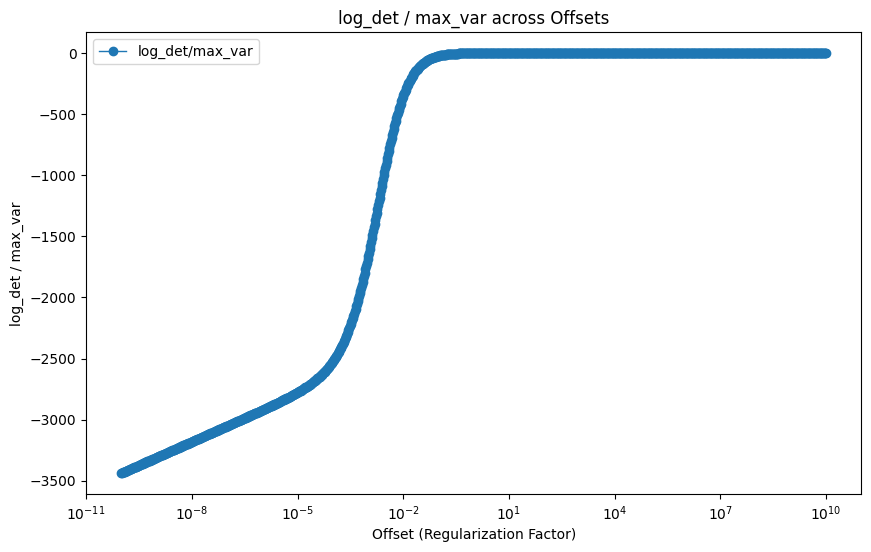

In [31]:
avg_metrics = D_mdtv.groupby('offset')[['max_var', 'log_det']].mean()

avg_metrics['log_det_max_var_ratio'] = avg_metrics['log_det'] / avg_metrics['max_var']

plt.figure(figsize=(10, 6))
plt.plot(avg_metrics.index, avg_metrics['log_det_max_var_ratio'], label='log_det/max_var', marker='o', linewidth=1)

plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('log_det / max_var')
plt.title('log_det / max_var across Offsets')
plt.legend()
plt.show()

/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


Text(0.5, 1.0, 'Correlation between log_det and max_var across Offsets')

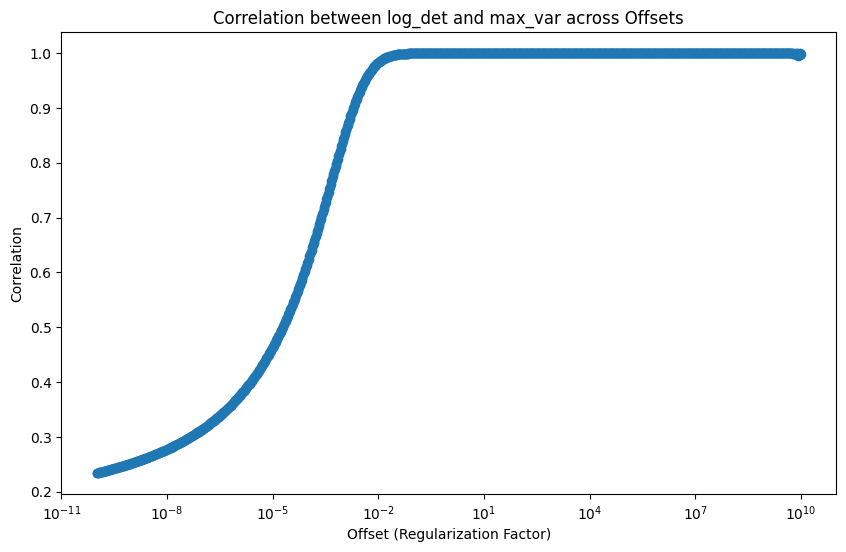

In [32]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between log_det and max_var across Offsets')


Text(0.5, 1.0, 'Correlation between min_est and max_var across Offsets')

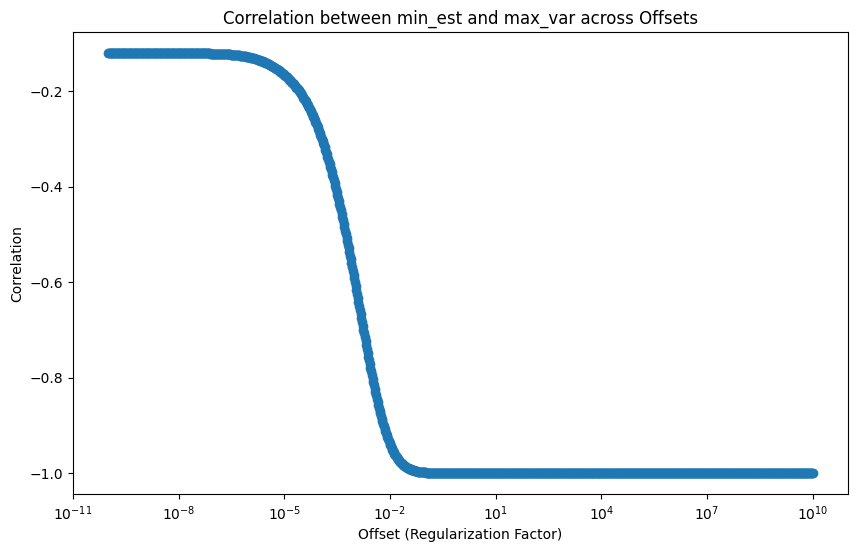

In [33]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    corr, _ = pearsonr(data['max_var'], data['min_est'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and max_var across Offsets')


/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


Text(0.5, 1.0, 'Correlation between min_est and log_det across Offsets')

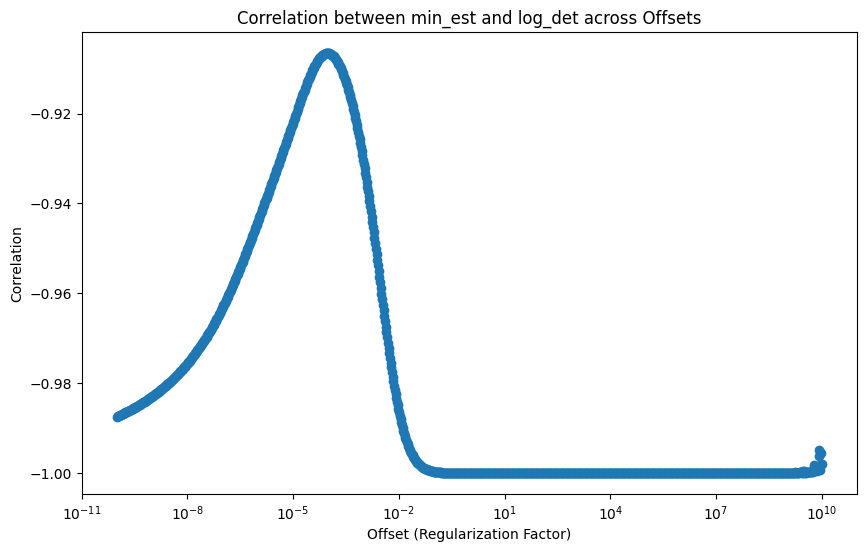

In [34]:
corr_list = []
# calculate Pearson's correlation for each offset
for offset in offsets:
    data = D_mdtv[D_mdtv['offset'] == offset]
    corr, _ = pearsonr(data['min_est'], data['log_det'])
    corr_list.append(corr)


#plot the correlations
plt.figure(figsize=(10, 6))
plt.plot(offsets, corr_list, label='Correlation', marker='o', linewidth=1)
plt.xscale('log')
plt.xlabel('Offset (Regularization Factor)')
plt.ylabel('Correlation')
plt.title('Correlation between min_est and log_det across Offsets')
